# 05 - Propensity Modelling (XGBoost + Optuna + SHAP)

CRED Market Entry and Segmentation Diagnostic - Shashank Tiwari, IIT Kharagpur

In [1]:
import sys, warnings, logging
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
import config
from src.utils import setup_logging
setup_logging(logging.INFO)
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 40)
FIG = config.FIGURES_DIR

In [2]:
import joblib
from src.propensity import create_labels, make_feature_matrix, split_data, evaluate_model, decile_analysis, beachhead_sizing
features = pd.read_csv(config.FEATURES_FILE)
y, info = create_labels(features)
X = make_feature_matrix(features)
X_train, X_test, y_train, y_test = split_data(X, y)
info

04:59:15 | INFO    | cred.propensity | Labels: credit_score >= 780 | rule rate 9.4% | after 5% noise 13.5% (6,365 positives)


{'credit_score_threshold': 780,
 'rule_positive_rate': 0.09427131848590059,
 'final_positive_rate': 0.13474892031501398,
 'n_flipped': 2344}

## Synthetic adoption label
Rule: credit_score >= threshold AND monthly spend > INR 15k AND Tier-1/2 AND age 25-45, then 5% of labels are flipped. The threshold auto-adjusts so the positive rate lands in 10-15%.

## Load the Optuna-tuned model
The 100-trial search runs inside `run_pipeline.py`; here we reload the artefact and re-score.

In [3]:
model = joblib.load(config.MODELS_DIR / 'xgboost_propensity.pkl')
study = joblib.load(config.MODELS_DIR / 'optuna_study.pkl')
baseline = joblib.load(config.MODELS_DIR / 'logistic_baseline.pkl')
pd.DataFrame([{'model': 'Logistic', **evaluate_model(baseline, X_test, y_test)}, {'model': 'XGBoost', **evaluate_model(model, X_test, y_test)}])

,model,roc_auc,pr_auc,threshold,precision,recall,f1
0,Logistic,0.802515,0.479428,0.272193,0.542576,0.605656,0.572383
1,XGBoost,0.825472,0.729819,0.480075,0.955056,0.667714,0.785945


In [4]:
print('best params:'); pd.Series(study.best_params)

best params:


max_depth             8.000000
learning_rate         0.160138
n_estimators        156.000000
min_child_weight      6.000000
subsample             0.666493
colsample_bytree      0.626605
gamma                 4.945340
reg_alpha             8.742862
reg_lambda            0.002922
dtype: float64

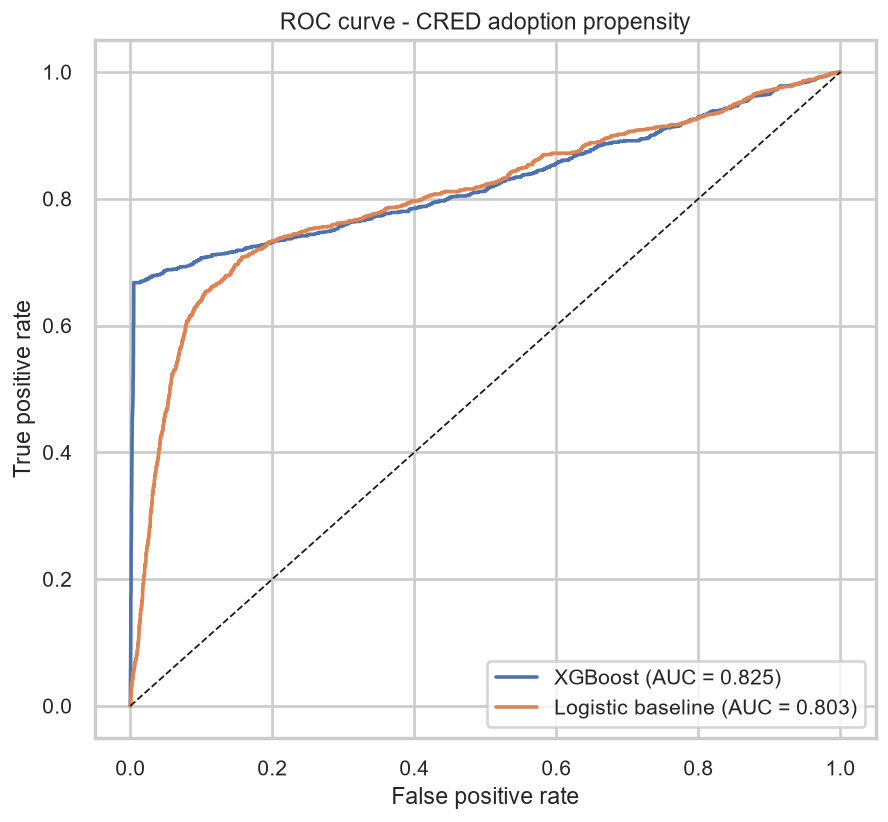

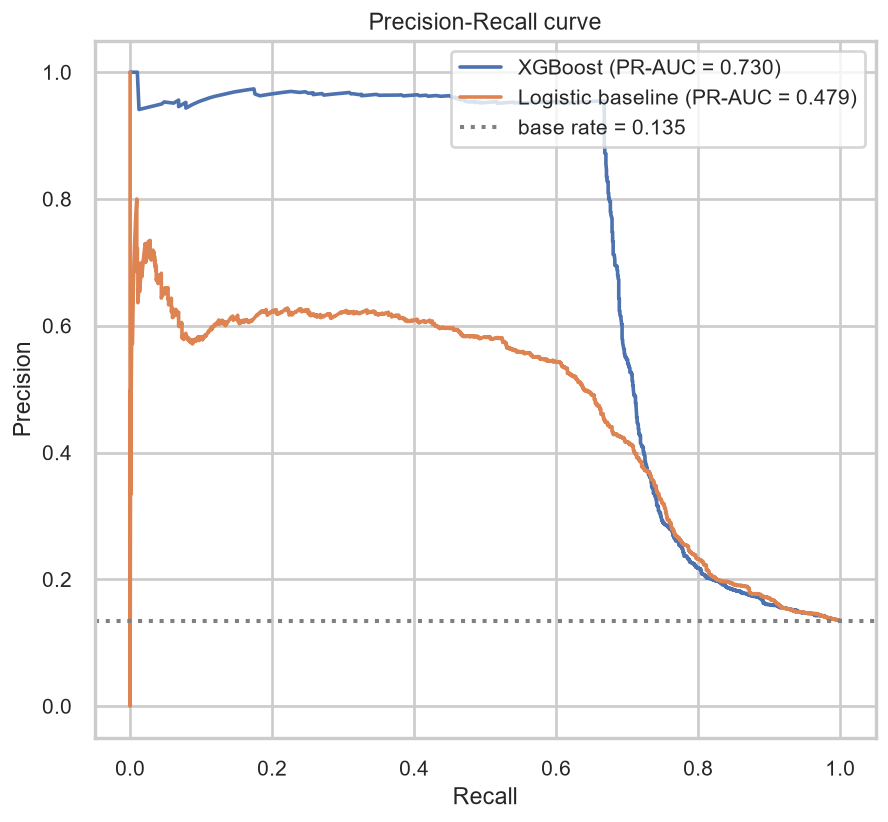

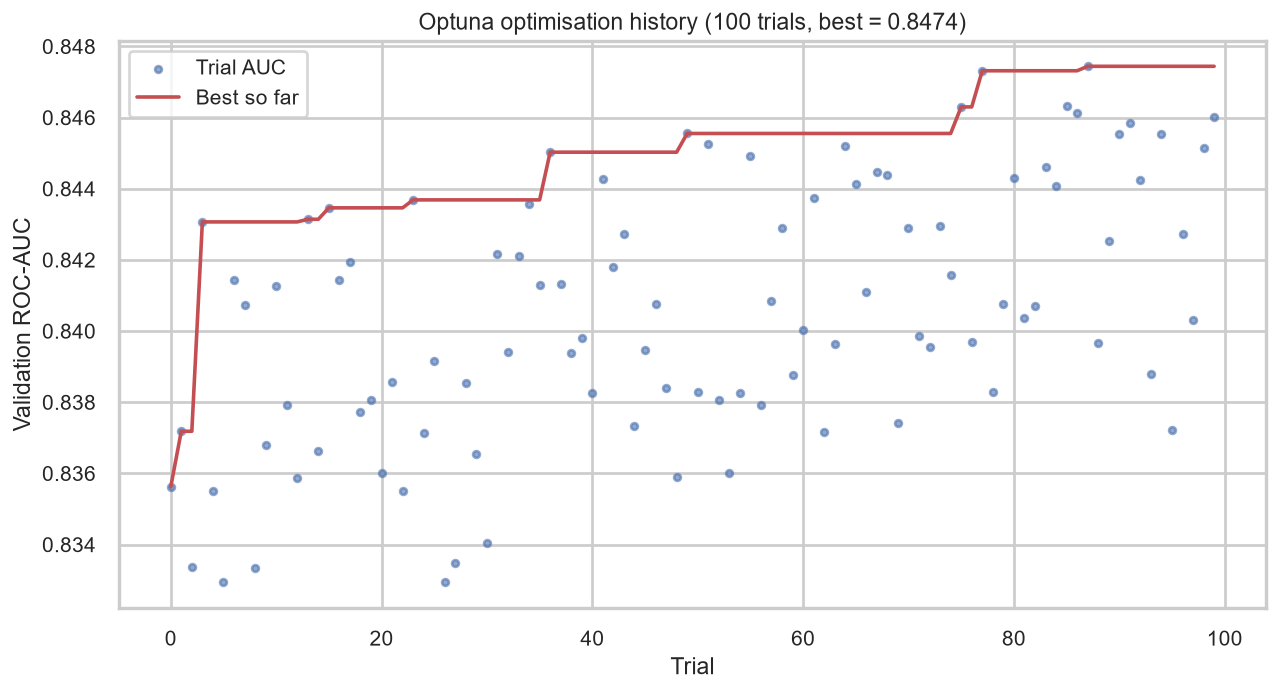

In [5]:
display(Image(FIG / 'roc_curve.png', width=550)); display(Image(FIG / 'pr_curve.png', width=550)); display(Image(FIG / 'optuna_optimization_history.png', width=800))

## Explainability

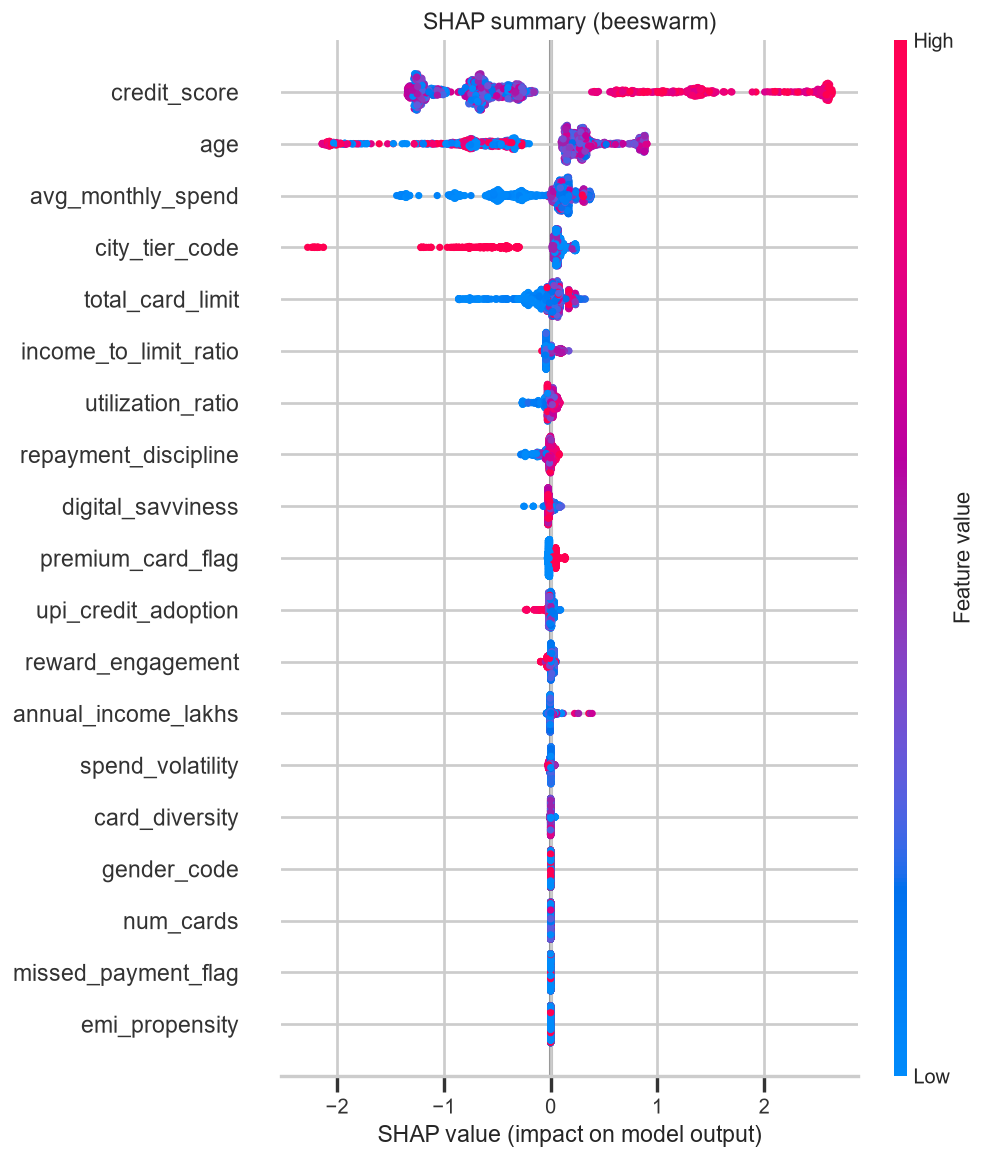

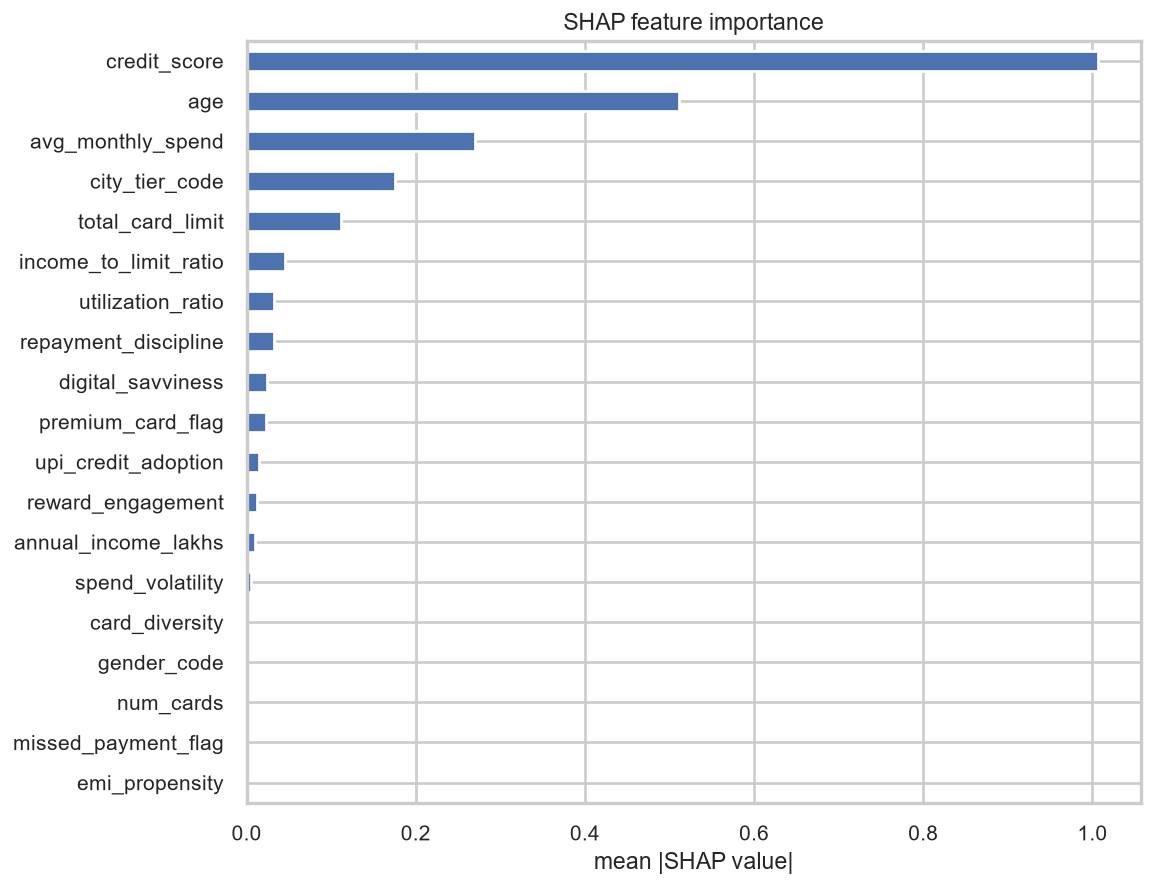

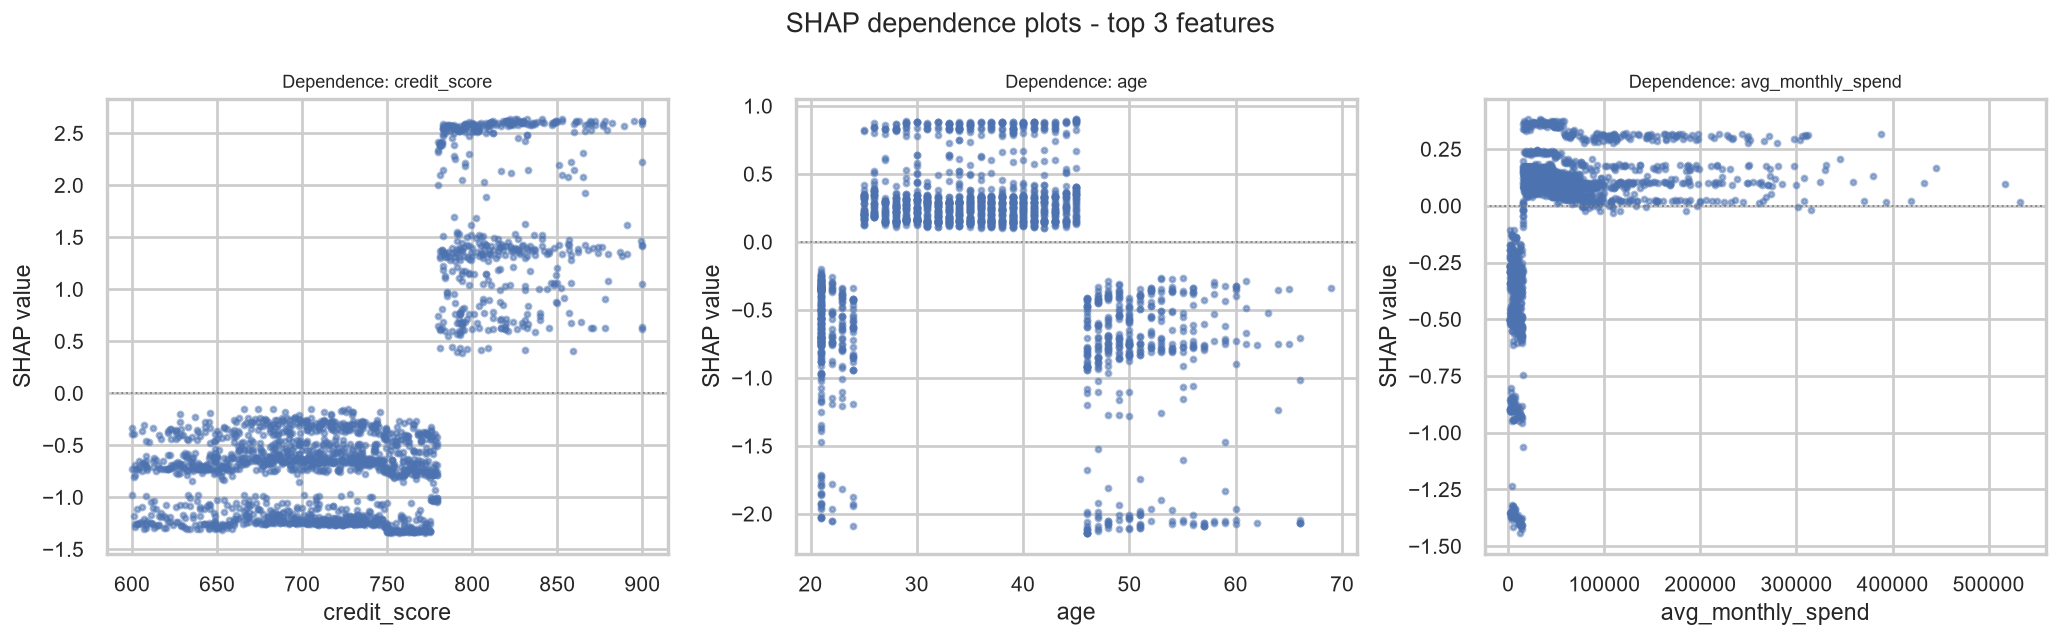

In [6]:
display(Image(FIG / 'shap_summary.png', width=800)); display(Image(FIG / 'shap_importance.png', width=700)); display(Image(FIG / 'shap_dependence_top3.png', width=1100))

## Decile lift and beachhead sizing

In [7]:
proba = model.predict_proba(X_test)[:, 1]
deciles = decile_analysis(y_test.to_numpy(), proba)
deciles.round(4)

04:59:18 | INFO    | cred.propensity | Top decile: adoption 89.9% (lift 6.68x) captures 66.8% of adopters


,decile,count,adopters,adoption_rate,min_score,mean_score,lift,capture,cumulative_capture,cumulative_lift,overall_rate
0,1,945,850,0.8995,0.1440,0.8568,6.6757,0.6677,0.6677,6.6771,0.1347
1,2,945,56,0.0593,0.0751,0.0964,0.4398,0.0440,0.7117,3.5585,0.1347
2,3,945,35,0.0370,0.0627,0.0681,0.2749,0.0275,0.7392,2.4640,0.1347
3,4,945,41,0.0434,0.0568,0.0593,0.3220,0.0322,0.7714,1.9285,0.1347
4,5,944,40,0.0424,0.0522,0.0545,0.3145,0.0314,0.8028,1.6057,0.1347
5,6,945,46,0.0487,0.0483,0.0503,0.3613,0.0361,0.8390,1.3983,0.1347
6,7,945,61,0.0646,0.0446,0.0463,0.4791,0.0479,0.8869,1.2670,0.1347
7,8,945,43,0.0455,0.0394,0.0420,0.3377,0.0338,0.9207,1.1508,0.1347
8,9,945,55,0.0582,0.0348,0.0371,0.4320,0.0432,0.9639,1.0710,0.1347
9,10,944,46,0.0487,0.0210,0.0316,0.3617,0.0361,1.0000,1.0000,0.1347


In [8]:
beachhead_sizing(deciles, n_holders=len(features))

04:59:18 | INFO    | cred.propensity | Beachhead: core 3.8M, with adjacent cohorts 11.4M holders


,cohort,deciles,share_of_market_pct,sample_holders,market_holders_M,adoption_rate,lift,share_of_adopters_pct
0,Core (decile 1),1,10,4723,3.8,0.8995,6.676,66.8
1,Adjacent (deciles 2-3),2-3,20,9447,7.6,0.0481,0.357,7.1
2,Beachhead total (deciles 1-3),1-2-3,30,14170,11.4,0.3319,2.463,73.9
3,Remaining market (deciles 4-10),4-5-6-7-8-9-10,70,33065,26.6,0.0502,0.373,26.1


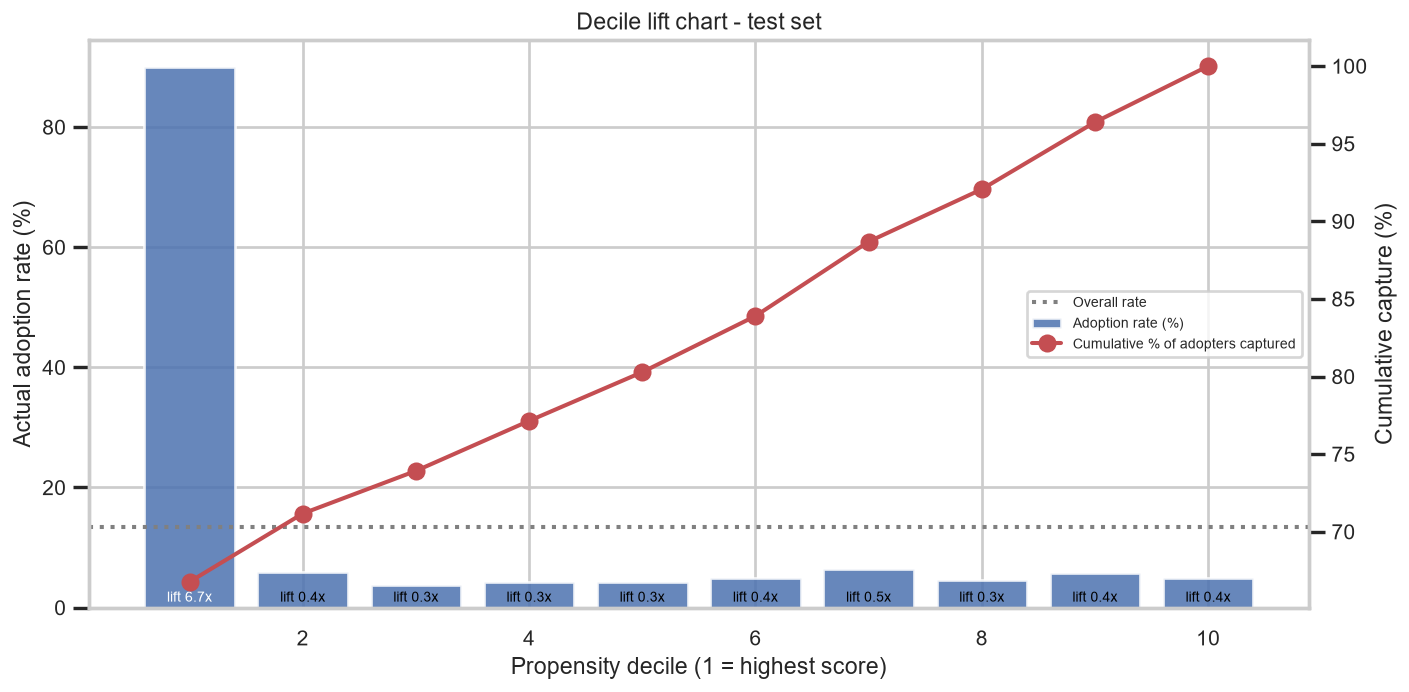

In [9]:
display(Image(FIG / 'decile_lift.png', width=900))